Notebook to simulate a geometric brownian motion:

$$  dS_t = rS_t dt + \sigma S_t dW_t $$


where: 

$S_t$ is the stock price at time t 

$r$ is the risk-free rate

$\sigma$ is the volatility

$W_t$ is a standard Brownian motion

Here it gonna simulate over 100 stock paths for a stock price

In [2]:
import numpy as np
import scipy as sp 
import diffrax as dx
import matplotlib.pyplot as plt
import jax.random as jr
import jax.numpy as jnp
import jax
import jax.scipy as jsp

In [9]:
print(jax.device_count())
print(jax.devices())

x = jnp.zeros((10,10))

y = x+x

print(y.device)

1
[CudaDevice(id=0)]
cuda:0


In [43]:
def solve_single_path(t0, t1, y0, r, sig, key):
    
    drift = lambda t, y, args : r * y     # f(t, y) = r * S
    diff = lambda t, y, args : sig * y    # g(t, y) = sig * S
    
    brow = dx.VirtualBrownianTree(t0, t1, tol=1e-6, shape=(), key=key)
    
    terms = dx.MultiTerm(
        dx.ODETerm(drift),
        dx.ControlTerm(diff, brow)
    )
    
    solver = dx.Heun()
    
    sol = dx.diffeqsolve(
        terms, solver, t0, t1, dt0=0.01, y0=y0,
        saveat=dx.SaveAt(t0=True, t1=True, steps=True)
    )
    
    #print(sol.controller_state)
    #print(sol.derivative(t0, True))
    #print(f"Sol for t0: {sol.t0} Sol for t1: {sol.t1} Sol for ts: {sol.ts}")
    return sol



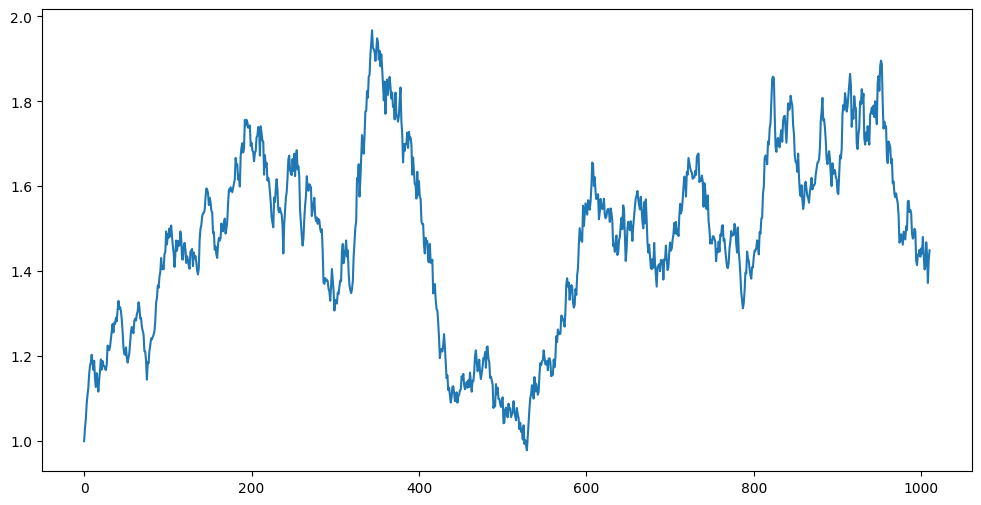

In [45]:
key = jr.PRNGKey(42)
sol = solve_single_path(0.0, 10.1, 1.0, 0.05, 0.2, key)

#print(sol)
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(sol.ys)

In [57]:
#print(keys)

@jax.jit(static_argnums=(0,))
def simulate_paths(n_paths, y0, r):
    keys = jr.split(jr.PRNGKey(42), n_paths)
    all_paths = jax.vmap(
        lambda k: solve_single_path(0.0, 20.0, y0, r, 0.1, k).ys
    )(keys)
    return all_paths

#paths = simulate_paths(10_000)
#print(paths.shape)
#print(paths.device)

In [ ]:
keys = jr.split(jr.PRNGKey(42), 10)

Array(3134548294, dtype=uint32)

In [ ]:
def plot_beautiful_gbm(paths, y0, r):
    # paths shape is (1000, 4097)
    num_steps = paths.shape[1]
    time_grid = np.linspace(sol.t0, sol.t1, num_steps)
    
    plt.figure(figsize=(12, 6), dpi=100)
    
    # 1. Plot individual paths with low alpha
    # We plot only 100 paths to keep the vector graphic light, but use all for stats
    plt.plot(time_grid, paths[:500].T, color='royalblue', alpha=0.1, lw=0.5)
    
    #expect = y0 * np.exp(r * time_grid) 
    
    #plt.plot(time_grid, expect, color='red', linestyle='--', lw=2, label='Theoretical (Expectation)')
    #plt.xlim(0, 2.5)
    # 2. Calculate and plot the mean path
    mean_path = np.mean(paths, axis=0)
    plt.plot(time_grid, mean_path, color='darkblue', lw=2, label='Mean Path')
    
    # 3. Calculate and plot 5th and 95th percentiles (the "Uncertainty Cone")
    p95 = np.percentile(paths, 95, axis=0)
    p05 = np.percentile(paths, 5, axis=0)
    plt.fill_between(time_grid, p05, p95, color='royalblue', alpha=0.2, label='5%-95% Range')
    
    # Styling
    plt.title(f"Geometric Brownian Motion: 1,000 Simulated Paths", fontsize=14)
    plt.xlabel("Time (t)", fontsize=12)
    plt.ylabel("Stock Price (St)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()
    
#plot_beautiful_gbm(paths,1.0, 0.05)

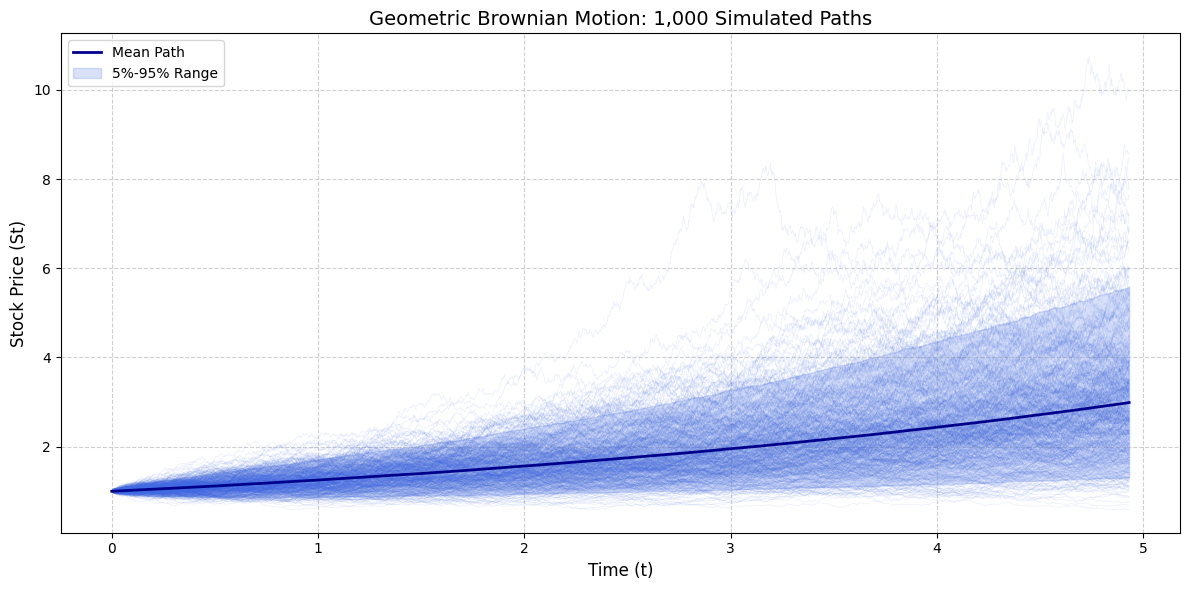

In [64]:
y0, r = 1.0, 0.05 
paths = simulate_paths(10_000, y0, r)
plot_beautiful_gbm(paths, y0 , r)